# Conformal Prediction

In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import seaborn as sns
import numpy as np
import numpy as np
import warnings
import os

In [35]:
model = load_model("model.h5")

In [66]:
# Define image dimensions and batch size
img_width, img_height = 64, 64
batch_size = 64
confidence_level = 0.95  # 95% confidence
alpha = 1 - confidence_level

# Data generators (no rescaling if model already does it)
datagen = ImageDataGenerator(rescale=1/255.0)

# Calibration data - MUST be representative!
calib_generator = datagen.flow_from_directory(
    directory='./data/calibration',
    target_size=(img_width, img_height),
    class_mode='binary',
    batch_size=batch_size,
    shuffle=False  # Critical for alignment
)

# Test data
test_generator = datagen.flow_from_directory(
    directory='./data/test_data_for_cal',
    target_size=(img_width, img_height),
    class_mode='binary',
    batch_size=batch_size,
    shuffle=False
)


Found 2000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


In [67]:
# =============================================
# STEP 1: Get calibrated probabilities
# =============================================
warnings.filterwarnings("ignore", category=RuntimeWarning)

def calibrate_probs(probs, temperature=2.0):
    """Temperature scaling for better calibration"""
    return 1 / (1 + np.exp(-(np.log(probs / (1 - probs)) / temperature)))

# Get raw model outputs
calib_probs = model.predict(calib_generator, verbose=1).squeeze()
calib_true_labels = calib_generator.labels

# Apply temperature scaling (tune this parameter)
temperature = 2.0
calib_probs_calibrated = calibrate_probs(calib_probs, temperature)

 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

/home/cegrib/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


In [68]:
# =============================================
# STEP 2: Compute non-conformity scores
# =============================================
# For binary classification: score = 1 - p for true class
calib_scores = np.where(
    calib_true_labels == 1,
    1 - calib_probs_calibrated,  # If true class is 1
    calib_probs_calibrated       # If true class is 0
)

In [69]:
# =============================================
# STEP 3: Compute conformal threshold (q_hat)
# =============================================
n = len(calib_scores)
q_hat = np.quantile(
    calib_scores,
    np.ceil((n + 1) * (1 - alpha)) / n,
    method='higher'
)
print(f"\nConformal threshold (q_hat) for {confidence_level:.0%} confidence: {q_hat:.4f}")


Conformal threshold (q_hat) for 95% confidence: 0.2192


In [70]:
# =============================================
# STEP 4: Generate prediction sets for test data
# =============================================
test_probs = model.predict(test_generator, verbose=1).squeeze()
test_probs_calibrated = calibrate_probs(test_probs, temperature)
test_true_labels = test_generator.labels

prediction_sets = []
for prob in test_probs_calibrated:
    included_classes = []
    if (1 - prob) <= q_hat:  # Include class 1
        included_classes.append(1)
    if prob <= q_hat:  # Include class 0
        included_classes.append(0)
    prediction_sets.append(included_classes)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


In [71]:
# =============================================
# STEP 5: Evaluate results
# =============================================
# Calculate empirical coverage
coverage = np.mean([test_true_labels[i] in pred_set 
                   for i, pred_set in enumerate(prediction_sets)])
print(f"Empirical Coverage: {coverage:.4f} (Expected ≥ {confidence_level:.0%})")

# Calculate average set size (ideal: close to 1)
avg_set_size = np.mean([len(s) for s in prediction_sets])
print(f"Average Prediction Set Size: {avg_set_size:.4f}")

Empirical Coverage: 0.9585 (Expected ≥ 95%)
Average Prediction Set Size: 0.9755



First 10 test predictions:
True: 0, Pred Set: [0], Prob: 0.000
True: 0, Pred Set: [0], Prob: 0.000
True: 0, Pred Set: [0], Prob: 0.000
True: 0, Pred Set: [0], Prob: 0.005
True: 0, Pred Set: [0], Prob: 0.000
True: 0, Pred Set: [0], Prob: 0.000
True: 0, Pred Set: [0], Prob: 0.000
True: 0, Pred Set: [0], Prob: 0.000
True: 0, Pred Set: [0], Prob: 0.054
True: 0, Pred Set: [0], Prob: 0.003


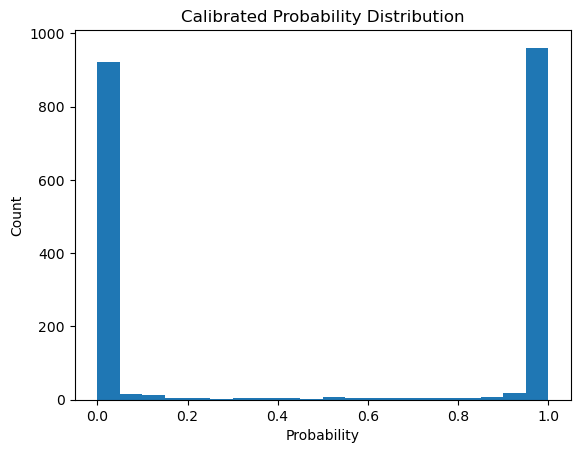

In [72]:
# =============================================
# STEP 6: Diagnostic Outputs
# =============================================
print("\nFirst 10 test predictions:")
for i in range(10):
    print(f"True: {test_true_labels[i]}, "
          f"Pred Set: {prediction_sets[i]}, "
          f"Prob: {test_probs_calibrated[i]:.3f}")

# Plot histogram of calibrated probabilities
import matplotlib.pyplot as plt
plt.hist(test_probs_calibrated, bins=20)
plt.title("Calibrated Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

In [73]:
# Check distribution of set types
from collections import Counter
set_counts = Counter([tuple(p) for p in prediction_sets])
print(f"Set types distribution: {set_counts}")

Set types distribution: Counter({(1,): 991, (0,): 960, (): 49})


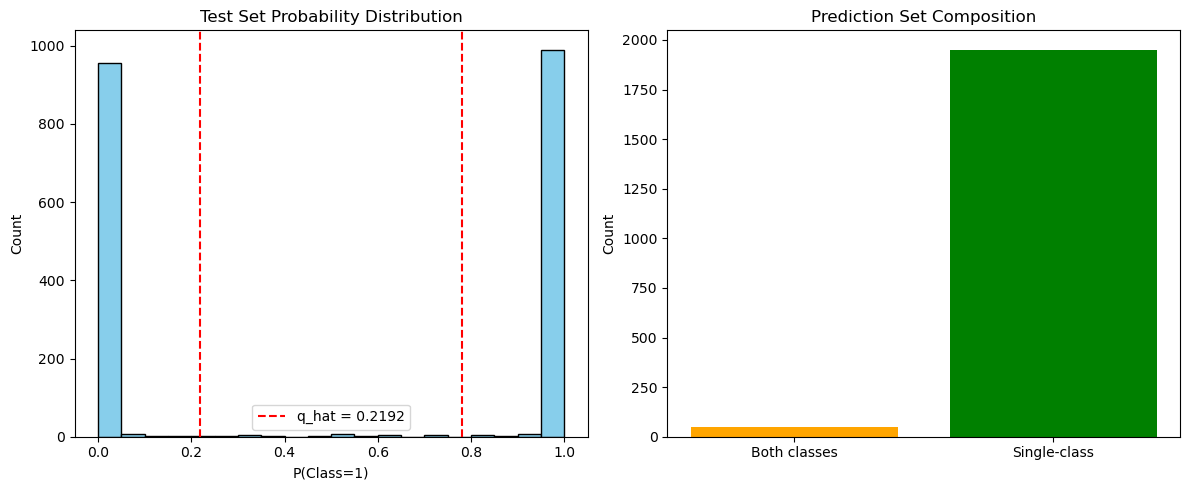


Prediction Set Types:
Counter({(1,): 991, (0,): 960, (): 49})


In [74]:
# Diagnostic visualizations
plt.figure(figsize=(12,5))

# Plot 1: Probability distribution
plt.subplot(1,2,1)
plt.hist(test_probs, bins=20, color='skyblue', edgecolor='black')
plt.axvline(x=q_hat, color='r', linestyle='--', label=f'q_hat = {q_hat:.4f}')
plt.axvline(x=1-q_hat, color='r', linestyle='--')
plt.title('Test Set Probability Distribution')
plt.xlabel('P(Class=1)')
plt.ylabel('Count')
plt.legend()

# Plot 2: Set size distribution
plt.subplot(1,2,2)
set_counts = Counter([len(s) for s in prediction_sets])
plt.bar(set_counts.keys(), set_counts.values(), color=['green','orange'])
plt.xticks([0,1], ['Both classes', 'Single-class'])
plt.title('Prediction Set Composition')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Print set type distribution
print("\nPrediction Set Types:")
print(Counter([tuple(s) for s in prediction_sets]))

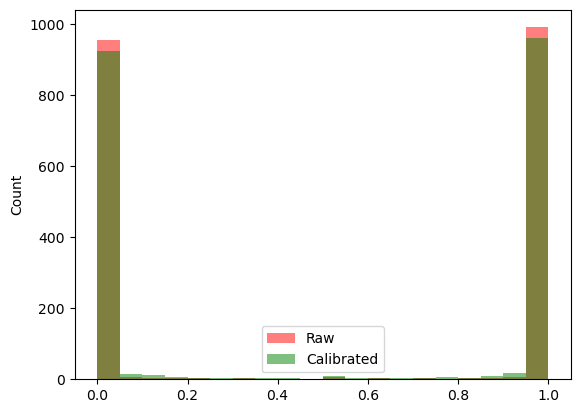

In [75]:
# Before calibration
plt.hist(test_probs, bins=20, alpha=0.5, label='Raw', color='red')
# After calibration
plt.hist(test_probs_calibrated, bins=20, alpha=0.5, label='Calibrated', color='green')
plt.ylabel('Count')
plt.legend()